# 1. Carga de datos

## 1.1. Lectura datos

In [299]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

In [300]:
# Ruta al archivo
file_path = "../../data/experiment_0.json"

df = pd.read_json(file_path)

print("="*70)
print("Primeras 5 filas:\n")
print(df.head(5).to_string(index=False))
print("="*70)

Primeras 5 filas:

 header_stamp  seq_id  t_rx                                          topic  valid  original_stamp          aux                      source_topic
        3.142     133 3.142 /robot/robotnik_base_control/odom_instrumented  False           3.105 4.853383e-07 /robot/robotnik_base_control/odom
        3.142     134 3.142 /robot/robotnik_base_control/odom_instrumented  False           3.128 4.684677e-07 /robot/robotnik_base_control/odom
        3.182     135 3.183 /robot/robotnik_base_control/odom_instrumented  False           3.149 4.853391e-07 /robot/robotnik_base_control/odom
        3.183     136 3.183 /robot/robotnik_base_control/odom_instrumented  False           3.170 4.684685e-07 /robot/robotnik_base_control/odom
        3.217     137 3.217 /robot/robotnik_base_control/odom_instrumented  False           3.191 4.853399e-07 /robot/robotnik_base_control/odom


## 1.2. Analisis de calidad

In [301]:
report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "nulls": df.isna().sum().values,
    "null_%": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

print("\n" + "="*70)
print("DATA QUALITY REPORT")
print("="*70)
print(report.to_string(index=False))
print("="*70)

print(f"\nTotal filas: {len(df)}")
print(f"Total columnas: {df.shape[1]}")
print(f"Total nulos: {df.isna().sum().sum()}")


DATA QUALITY REPORT
        column   dtype  nulls  null_%  unique_values
  header_stamp float64      0     0.0          48798
        seq_id   int64      0     0.0          55902
          t_rx float64      0     0.0          47072
         topic     str      0     0.0              5
         valid    bool      0     0.0              2
original_stamp float64      0     0.0          56875
           aux float64      0     0.0          21799
  source_topic     str      0     0.0              5

Total filas: 77029
Total columnas: 8
Total nulos: 0


# 2. Normalizacion

## 2.1. Unificar timestamps

In [302]:
df["t_rx"] = df["t_rx"].astype(float)
df["original_stamp"] = df["original_stamp"].astype(float)
df["header_stamp"] = df["header_stamp"].astype(float)

topics = [
    "/robot/robotnik_base_control/odom",
    "/robot/move_base_simple/goal",
    "/robot/amcl_pose"
]

df["final_timestamp"] = df["original_stamp"].where(
    df["source_topic"].isin(topics),
    df["header_stamp"]
)

In [303]:
df = df.sort_values("final_timestamp").reset_index(drop=True)

# 3. Segmentación por goal

## 3.1 Crear ventanas temporales

In [304]:
segments = []

goal_times = df[df["source_topic"] == "/robot/move_base_simple/goal"]["final_timestamp"].values

for i in range(len(goal_times)):
    t_start = goal_times[i]
    t_end = goal_times[i+1] if i < len(goal_times)-1 else df["final_timestamp"].max()

    segment = df[(df["final_timestamp"] >= t_start) & (df["final_timestamp"] < t_end)].copy()
    segment["goal_id"] = i

    segments.append(segment)

df_segmented = pd.concat(segments).reset_index(drop=True)

In [305]:
print("="*70)
print("Primeras 5 filas:\n")
print(df_segmented.head(5).to_string(index=False))
print("="*70)

Primeras 5 filas:

 header_stamp  seq_id   t_rx                                          topic  valid  original_stamp      aux                      source_topic  final_timestamp  goal_id
       21.393       1 21.393      /robot/move_base_simple/goal_instrumented   True          20.292 0.000000      /robot/move_base_simple/goal           20.292        0
       20.322     952 20.322 /robot/robotnik_base_control/odom_instrumented   True          20.305 0.338791 /robot/robotnik_base_control/odom           20.305        0
       20.372     953 20.373 /robot/robotnik_base_control/odom_instrumented   True          20.322 0.338791 /robot/robotnik_base_control/odom           20.322        0
       20.372     954 20.373 /robot/robotnik_base_control/odom_instrumented   True          20.348 0.338802 /robot/robotnik_base_control/odom           20.348        0
       20.372     955 20.373 /robot/robotnik_base_control/odom_instrumented   True          20.368 0.338791 /robot/robotnik_base_control/odom

## 3.2 Verificación

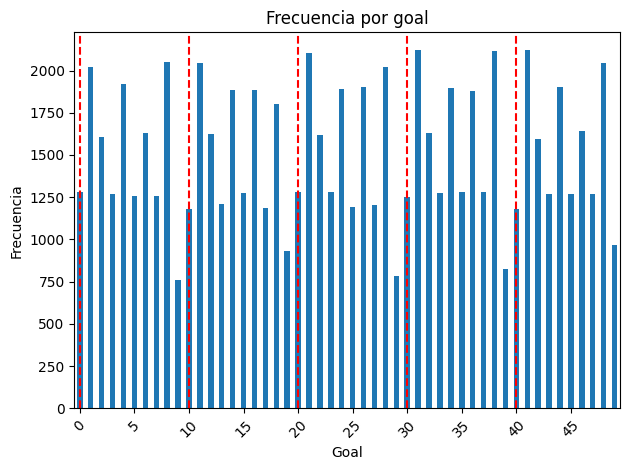

In [306]:

counts = df_segmented["goal_id"].value_counts().sort_index()

plt.figure()
counts.plot(kind="bar")

# Añadir líneas verticales cada 10 valores
for i, goal in enumerate(counts.index):
    if goal % 10 == 0:
        plt.axvline(x=i, color="red", linestyle="--", )



plt.title("Frecuencia por goal")
plt.xlabel("Goal")
plt.ylabel("Frecuencia")
step = 5  # muestra 1 de cada 5 etiquetas (ajusta según densidad)
plt.xticks(
    ticks=range(0, len(counts), step),
    labels=counts.index[::step],
    rotation=45
)
plt.tight_layout()

plt.show()

# 4. Detección de eventos

## 4.1. Nearest + DTW matching

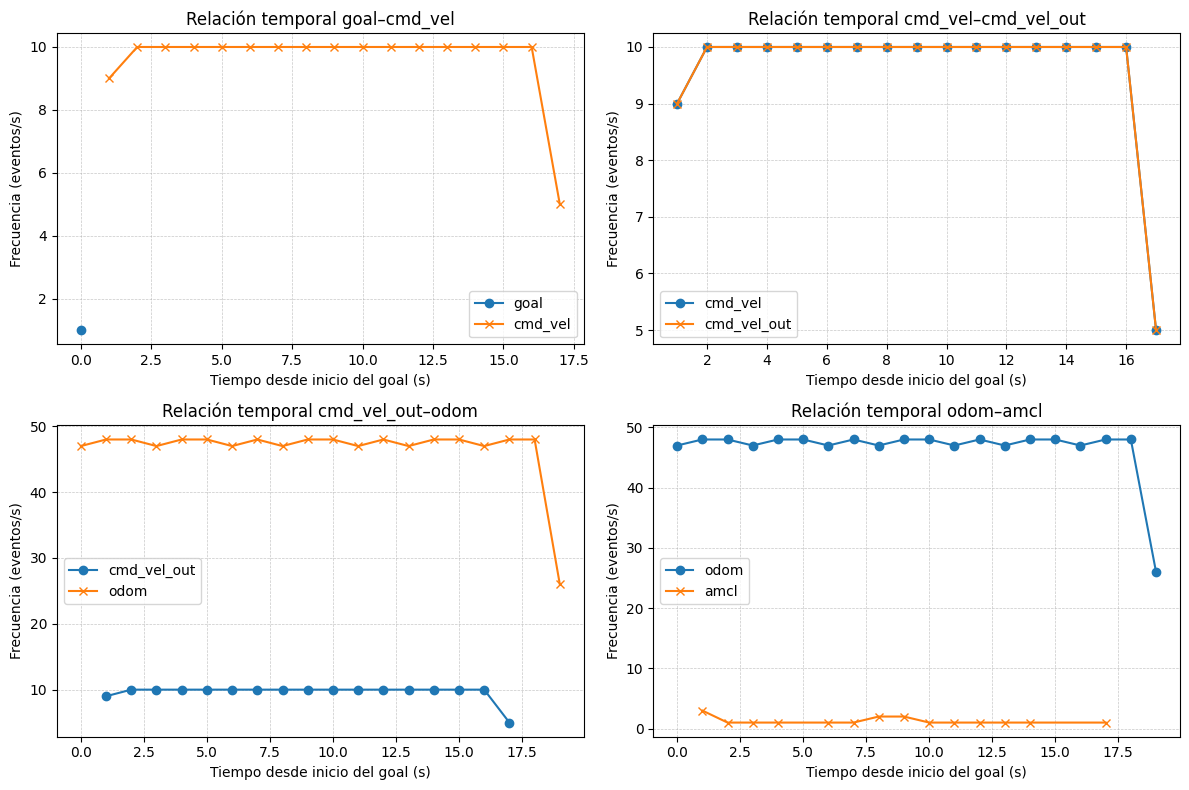

In [307]:

# --- Selección de goal ---
gid = 0
segment = df_segmented[df_segmented["goal_id"] == gid]

# --- Tiempo de referencia (goal) ---
t0 = segment.loc[
    segment["topic"] == "/robot/move_base_simple/goal_instrumented",
    "final_timestamp"
].iloc[0]

# --- Mapeo de nombres coherente ---
label_map = {
    "/robot/move_base_simple/goal_instrumented": "goal",
    "/robot/move_base/cmd_vel_instrumented": "cmd_vel",
    "/robot/robotnik_base_control/cmd_vel_instrumented": "cmd_vel_out",
    "/robot/robotnik_base_control/odom_instrumented": "odom",
    "/robot/amcl_pose_instrumented": "amcl",
}

# --- Función de frecuencia por segundo ---
def compute_frequency(segment, topic, t0):
    df = segment[segment["topic"] == topic].copy()
    
    if df.empty:
        return None
    
    df["t_rel"] = df["final_timestamp"] - t0
    df["sec"] = np.floor(df["t_rel"]).astype(int)
    
    return df.groupby("sec").size()

# --- Definición de pares y títulos coherentes ---
pairs = [
    ("/robot/move_base_simple/goal_instrumented",
     "/robot/move_base/cmd_vel_instrumented",
     "Relación temporal goal–cmd_vel"),

    ("/robot/move_base/cmd_vel_instrumented",
     "/robot/robotnik_base_control/cmd_vel_instrumented",
     "Relación temporal cmd_vel–cmd_vel_out"),

    ("/robot/robotnik_base_control/cmd_vel_instrumented",
     "/robot/robotnik_base_control/odom_instrumented",
     "Relación temporal cmd_vel_out–odom"),

    ("/robot/robotnik_base_control/odom_instrumented",
     "/robot/amcl_pose_instrumented",
     "Relación temporal odom–amcl"),
]

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (t1, t2, title) in zip(axes, pairs):

    f1 = compute_frequency(segment, t1, t0)
    f2 = compute_frequency(segment, t2, t0)

    if f1 is not None:
        ax.plot(f1.index, f1.values, marker='o',
                label=label_map[t1])

    if f2 is not None:
        ax.plot(f2.index, f2.values, marker='x',
                label=label_map[t2])

    ax.set_title(title)
    ax.set_xlabel("Tiempo desde inicio del goal (s)")
    ax.set_ylabel("Frecuencia (eventos/s)")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend()

plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/asynchronous_event_frequencies.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

In [ ]:
events = []
total_goals = 0
discarded_goals = 0

for gid, segment in df_segmented.groupby("goal_id"):
    total_goals += 1

    # --- GOAL ---
    goal = segment[segment["topic"] == "/robot/move_base_simple/goal_instrumented"]
    if goal.empty:
        discarded_goals += 1
        continue
    t_goal = goal["final_timestamp"].iloc[0]

    # --- CMD ---
    cmd = segment[
        (segment["topic"] == "/robot/move_base/cmd_vel_instrumented") &
        (segment["final_timestamp"] > t_goal)
    ]
    if cmd.empty:
        discarded_goals += 1
        continue
    t_cmd = cmd["final_timestamp"].iloc[0]

    # --- CMD_OUT ---
    cmd_out = segment[
        (segment["topic"] == "/robot/robotnik_base_control/cmd_vel_instrumented") &
        (segment["final_timestamp"] > t_cmd)
    ]
    if cmd_out.empty:
        discarded_goals += 1
        continue
    t_cmd_out = cmd_out["final_timestamp"].iloc[0]

    # =========================
    # DTW: CMD_OUT → ODOM
    # =========================
    cmd_out_times = np.sort(
        segment[
            (segment["topic"] == "/robot/robotnik_base_control/cmd_vel_instrumented") &
            (segment["final_timestamp"] > t_cmd)
        ]["final_timestamp"].values
    )

    odom_times = np.sort(
        segment[
            (segment["topic"] == "/robot/robotnik_base_control/odom_instrumented") &
            (segment["final_timestamp"] > t_cmd_out)
        ]["final_timestamp"].values
    )

    if len(cmd_out_times) == 0 or len(odom_times) == 0:
        discarded_goals += 1
        continue

    _, path = fastdtw(
        cmd_out_times.reshape(-1,1),
        odom_times.reshape(-1,1),
        dist=euclidean
    )

    idx_cmd_out = np.argmin(np.abs(cmd_out_times - t_cmd_out))

    t_odom = None
    for i, j in path:
        if i == idx_cmd_out:
            t_odom = odom_times[j]
            break

    if t_odom is None or t_odom <= t_cmd_out:
        discarded_goals += 1
        continue

    # =========================
    # DTW: ODOM → AMCL
    # =========================
    odom_times = np.sort(
        segment[
            (segment["topic"] == "/robot/robotnik_base_control/odom_instrumented") &
            (segment["final_timestamp"] > t_cmd_out)
        ]["final_timestamp"].values
    )

    amcl_times = np.sort(
        segment[
            (segment["topic"] == "/robot/amcl_pose_instrumented") &
            (segment["final_timestamp"] > t_odom)
        ]["final_timestamp"].values
    )

    if len(amcl_times) == 0:
        discarded_goals += 1
        continue

    _, path = fastdtw(
        odom_times.reshape(-1,1),
        amcl_times.reshape(-1,1),
        dist=euclidean
    )

    idx_odom = np.argmin(np.abs(odom_times - t_odom))

    t_amcl = None
    for i, j in path:
        if i == idx_odom:
            t_amcl = amcl_times[j]
            break

    if t_amcl is None or t_amcl <= t_odom:
        discarded_goals += 1
        continue

    # --- SAVE ---
    events.append({
        "goal_id": gid,
        "t_goal": t_goal,
        "t_cmd": t_cmd,
        "t_cmd_out": t_cmd_out,
        "t_odom": t_odom,
        "t_amcl": t_amcl
    })

df_events = pd.DataFrame(events)

print("="*70)
print(f"Total goals: {total_goals}")
print(f"Descartados: {discarded_goals}")
print(f"% descartados: {discarded_goals / total_goals * 100:.2f}%")
print("="*70)

Total goals: 50
Descartados: 0
% descartados: 0.00%


In [309]:
invalid_order = df_events[
    ~(
        (df_events["t_goal"] <= df_events["t_cmd"]) &
        (df_events["t_cmd"] <= df_events["t_cmd_out"]) &
        (df_events["t_cmd_out"] <= df_events["t_odom"]) &
        (df_events["t_odom"] <= df_events["t_amcl"])
    )
]
print("="*70)
print(f"Eventos con orden temporal inválido: {len(invalid_order)}")
print("-"*70)
print(f"Filas totales: {len(df_events)}")
print(f"Columnas: {df_events.shape[1]}")
print("-"*70)
print("Primeras 5 filas:\n")
print(df_events.head(5).to_string(index=False))
print("-"*70)
print("="*70)

Eventos con orden temporal inválido: 0
----------------------------------------------------------------------
Filas totales: 50
Columnas: 6
----------------------------------------------------------------------
Primeras 5 filas:

 goal_id  t_goal   t_cmd  t_cmd_out  t_odom  t_amcl
       0  20.292  22.437     22.537  22.553  22.647
       1  39.836  41.956     42.056  42.062  42.542
       2  69.906  71.958     71.959  71.966  72.900
       3  94.172  96.299     96.399  96.410  97.018
       4 113.667 115.853    115.952 115.961 116.097
----------------------------------------------------------------------


## 4.2. Normalización de timestamps

In [310]:
time_cols = ["t_cmd", "t_cmd_out", "t_odom", "t_amcl", "t_goal"]

t0 = df_events["t_goal"].copy()

for col in time_cols:
    df_events[col] = df_events[col] - t0

In [311]:
print("="*70)
print(f"Filas totales: {len(df_events)}")
print(f"Columnas: {df_events.shape[1]}")
print("-"*70)
print("Primeras 5 filas:\n")
print(df_events.head(5).to_string(index=False))
print("-"*70)
print("="*70)

Filas totales: 50
Columnas: 6
----------------------------------------------------------------------
Primeras 5 filas:

 goal_id  t_goal  t_cmd  t_cmd_out  t_odom  t_amcl
       0     0.0  2.145      2.245   2.261   2.355
       1     0.0  2.120      2.220   2.226   2.706
       2     0.0  2.052      2.053   2.060   2.994
       3     0.0  2.127      2.227   2.238   2.846
       4     0.0  2.186      2.285   2.294   2.430
----------------------------------------------------------------------


# 5. Calculo de latencias

## 5.1 Definir métricas

In [312]:
df_events["L_plan_control"] = df_events["t_cmd"] - df_events["t_goal"]
df_events["L_mux"]          = df_events["t_cmd_out"] - df_events["t_cmd"]
df_events["L_exec"]         = df_events["t_odom"] - df_events["t_cmd_out"]
df_events["L_local"]        = df_events["t_amcl"] - df_events["t_odom"]

df_events["L_e2e_odom"]          = df_events["t_odom"] - df_events["t_goal"]

df_events["L_e2e_amcl"]     = df_events["t_amcl"] - df_events["t_goal"]


In [313]:
latency_cols = ["L_plan_control", "L_mux", "L_exec", "L_local", "L_e2e_odom", "L_e2e_amcl"]

print("="*70)
print(f"Filas totales: {len(df_events)}")
print(f"Columnas: {df_events.shape[1]}")
print("-"*70)
print("Primeras 5 filas:\n")
print(df_events[latency_cols].head(5).to_string(index=False))
print("-"*70)
print("="*70)

Filas totales: 50
Columnas: 12
----------------------------------------------------------------------
Primeras 5 filas:

 L_plan_control  L_mux  L_exec  L_local  L_e2e_odom  L_e2e_amcl
          2.145  0.100   0.016    0.094       2.261       2.355
          2.120  0.100   0.006    0.480       2.226       2.706
          2.052  0.001   0.007    0.934       2.060       2.994
          2.127  0.100   0.011    0.608       2.238       2.846
          2.186  0.099   0.009    0.136       2.294       2.430
----------------------------------------------------------------------


# 6. Validación y limpieza

In [258]:
# Comprobacion de que no hay overlap o intervalos mal definidos
L_e2e_odom_sum          = df_events["L_plan_control"] + df_events["L_mux"] + df_events["L_exec"]

L_e2e_amcl_sum     = df_events["L_plan_control"] + df_events["L_mux"] + df_events["L_exec"] + df_events["L_local"]

L_e2e_odom_error = L_e2e_odom_sum - df_events["L_e2e_odom"]
L_e2e_amcl_error = L_e2e_amcl_sum - df_events["L_e2e_amcl"]

tolerance = 1e-6 

L_e2e_odom_inconsistent = df_events[L_e2e_odom_error.abs() > tolerance]
L_e2e_amcl_inconsistent = df_events[L_e2e_amcl_error.abs() > tolerance]

print("="*70)
print("Latencia Odom - Error absoluto medio:", L_e2e_odom_error.abs().mean())
print("Latencia Odom - Error máximo:", L_e2e_odom_error.abs().max())
print(f"Latencia Odom - Eventos inconsistentes: {len(L_e2e_odom_inconsistent)}")
print("Latencia AMCL - Error absoluto medio:", L_e2e_amcl_error.abs().mean())
print("Latencia AMCL - Error máximo:", L_e2e_amcl_error.abs().max())
print(f"Latencia AMCL - Eventos inconsistentes: {len(L_e2e_amcl_inconsistent)}")

print("="*70)

Latencia Odom - Error absoluto medio: 0.0
Latencia Odom - Error máximo: 0.0
Latencia Odom - Eventos inconsistentes: 0
Latencia AMCL - Error absoluto medio: 0.0
Latencia AMCL - Error máximo: 0.0
Latencia AMCL - Eventos inconsistentes: 0


In [259]:
# Todas las latencias deben ser >= 0
cols = ["L_plan_control","L_mux","L_exec","L_local","L_e2e_odom","L_e2e_amcl"]
print("="*70)
print((df_events[cols] >= 0).all())
print("="*70)


L_plan_control    True
L_mux             True
L_exec            True
L_local           True
L_e2e_odom        True
L_e2e_amcl        True
dtype: bool


# 7. Análisis estadístico

## 7.1 Métricas básicas

In [314]:
cols = ["L_plan_control","L_mux","L_exec","L_local","L_e2e_odom","L_e2e_amcl"]

stats = df_events[cols].agg(["mean","std","min","max","median"])
print("="*70)
print(stats)
print("="*70)


        L_plan_control     L_mux    L_exec  L_local  L_e2e_odom  L_e2e_amcl
mean          2.116680  0.069800  0.011520  0.30102    2.198000    2.499020
std           0.056024  0.044401  0.005884  0.21300    0.066243    0.224725
min           2.009000  0.001000  0.001000  0.00700    2.060000    2.164000
max           2.221000  0.103000  0.021000  0.93400    2.315000    2.994000
median        2.120500  0.099000  0.011000  0.26050    2.204500    2.454000


## 7.2 Percentiles

In [261]:
percentiles = df_events[cols].quantile([0.5, 0.9, 0.95, 0.99])
print("="*70)
print(percentiles)
print("="*70)


      L_plan_control    L_mux  L_exec  L_local  L_e2e_odom  L_e2e_amcl
0.50         1.12250  0.09950   0.010  0.40550     1.20050     1.61850
0.90         1.18620  0.10200   0.020  0.77350     1.28200     2.00230
0.95         1.20985  0.10255   0.020  1.25210     1.30975     2.44965
0.99         1.22204  0.10400   0.021  1.41849     1.33128     2.64965


## 7.3 Variabilidad relativa

In [262]:
cv = df_events[cols].std() / df_events[cols].mean()
print("="*70)
print(cv)
print("="*70)


L_plan_control    0.050958
L_mux             0.635008
L_exec            0.589158
L_local           0.722606
L_e2e_odom        0.057293
L_e2e_amcl        0.202179
dtype: float64


## 7.4 Contribución por etapa

In [263]:
contrib = df_events[["L_plan_control","L_mux","L_exec","L_local"]].mean()
contrib_amcl = contrib / df_events["L_e2e_amcl"].mean()
print("="*70)
print(contrib_amcl)
print("="*70)


L_plan_control    0.671683
L_mux             0.042286
L_exec            0.006617
L_local           0.279414
dtype: float64


## 7.5 Detección de outliers por percentil (P99)

In [264]:
cols = ["L_plan_control","L_mux","L_exec","L_local","L_e2e_odom","L_e2e_amcl"]

results = {}

for col in cols:
    p99 = df_events[col].quantile(0.99)
    
    outliers = df_events[df_events[col] > p99]
    
    results[col] = {
        "p99": p99,
        "n_outliers": len(outliers),
        "perc_outliers": len(outliers) / len(df_events) * 100
    }

# Mostrar resultados
print("="*70)
for col, res in results.items():
    print(f"\n--- {col} ---")
    print(f"P99: {res['p99']:.4f}")
    print(f"Nº outliers: {res['n_outliers']}")
    print(f"% outliers: {res['perc_outliers']:.2f}%")
print("="*70)



--- L_plan_control ---
P99: 1.2220
Nº outliers: 1
% outliers: 2.00%

--- L_mux ---
P99: 0.1040
Nº outliers: 1
% outliers: 2.00%

--- L_exec ---
P99: 0.0210
Nº outliers: 1
% outliers: 2.00%

--- L_local ---
P99: 1.4185
Nº outliers: 1
% outliers: 2.00%

--- L_e2e_odom ---
P99: 1.3313
Nº outliers: 1
% outliers: 2.00%

--- L_e2e_amcl ---
P99: 2.6497
Nº outliers: 1
% outliers: 2.00%


# 8. Visualización

## 8.1 Histogramas

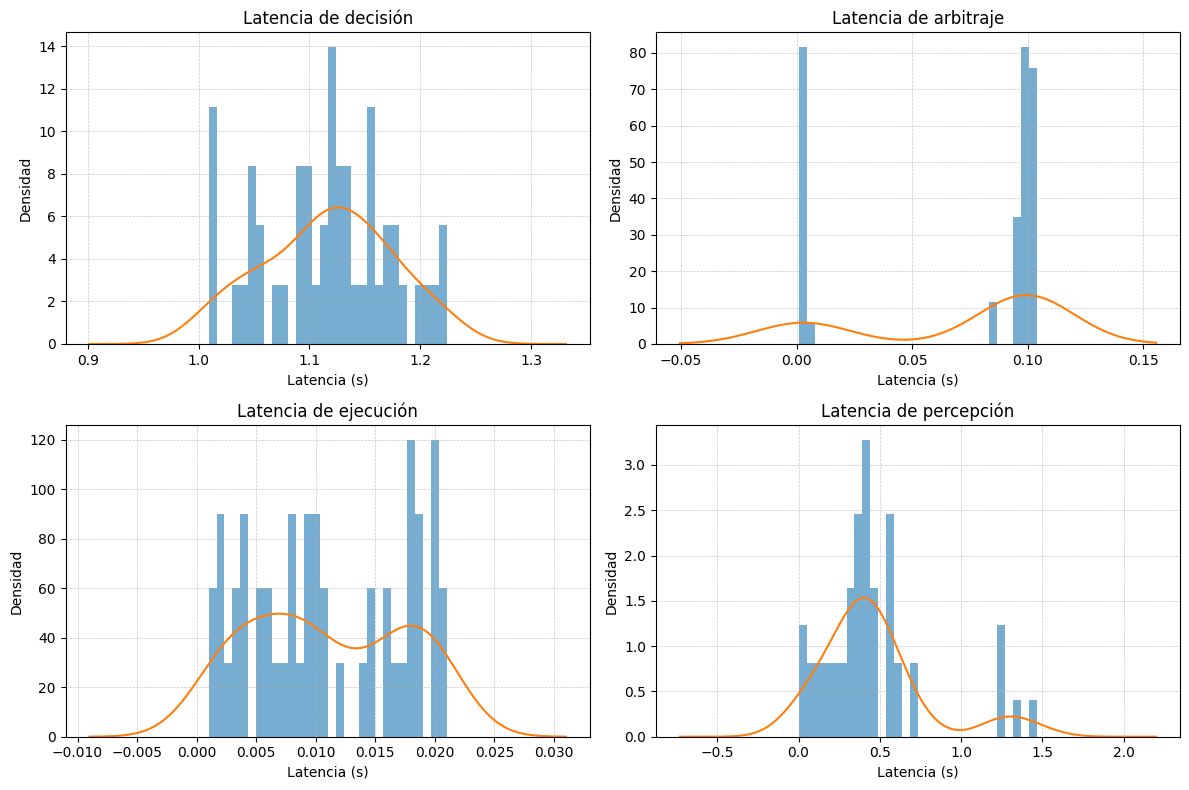

In [265]:
cols = ["L_plan_control","L_mux","L_exec","L_local"]

labels = {
    "L_plan_control": "Latencia de decisión",
    "L_mux": "Latencia de arbitraje",
    "L_exec": "Latencia de ejecución",
    "L_local": "Latencia de percepción"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    # Histograma
    df_events[col].plot(kind="hist", bins=30, density=True, ax=ax, alpha=0.6)
    
    # KDE
    df_events[col].plot(kind="kde", ax=ax)
    
    ax.set_title(labels[col])
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("Densidad")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/subsystem_latency_density_distribution.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

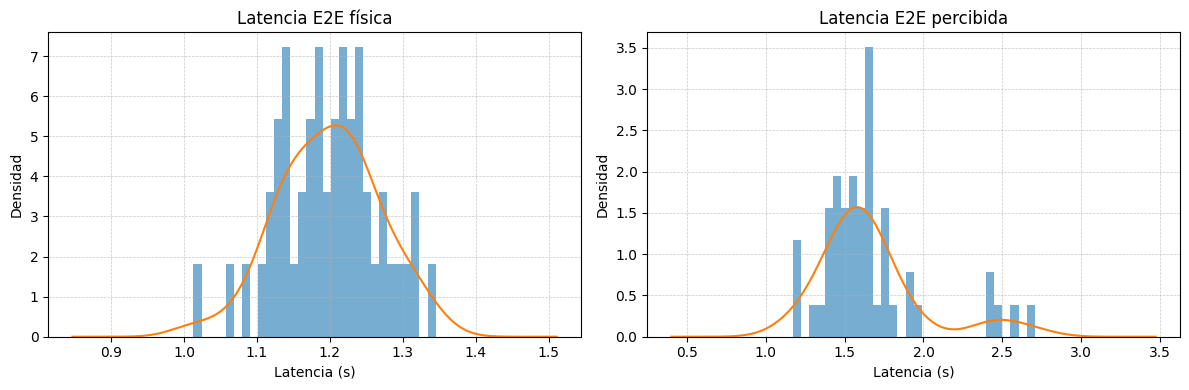

In [266]:
cols = ["L_e2e_odom","L_e2e_amcl"]

labels = {
    "L_e2e_odom": "Latencia E2E física",
    "L_e2e_amcl": "Latencia E2E percibida"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    # Histograma
    df_events[col].plot(kind="hist", bins=30, density=True, ax=ax, alpha=0.6)
    
    # KDE
    df_events[col].plot(kind="kde", ax=ax)
    
    ax.set_title(labels[col])
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("Densidad")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/e2e_latency_density_distribution.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

plt.show()

## 8.2. Boxplot

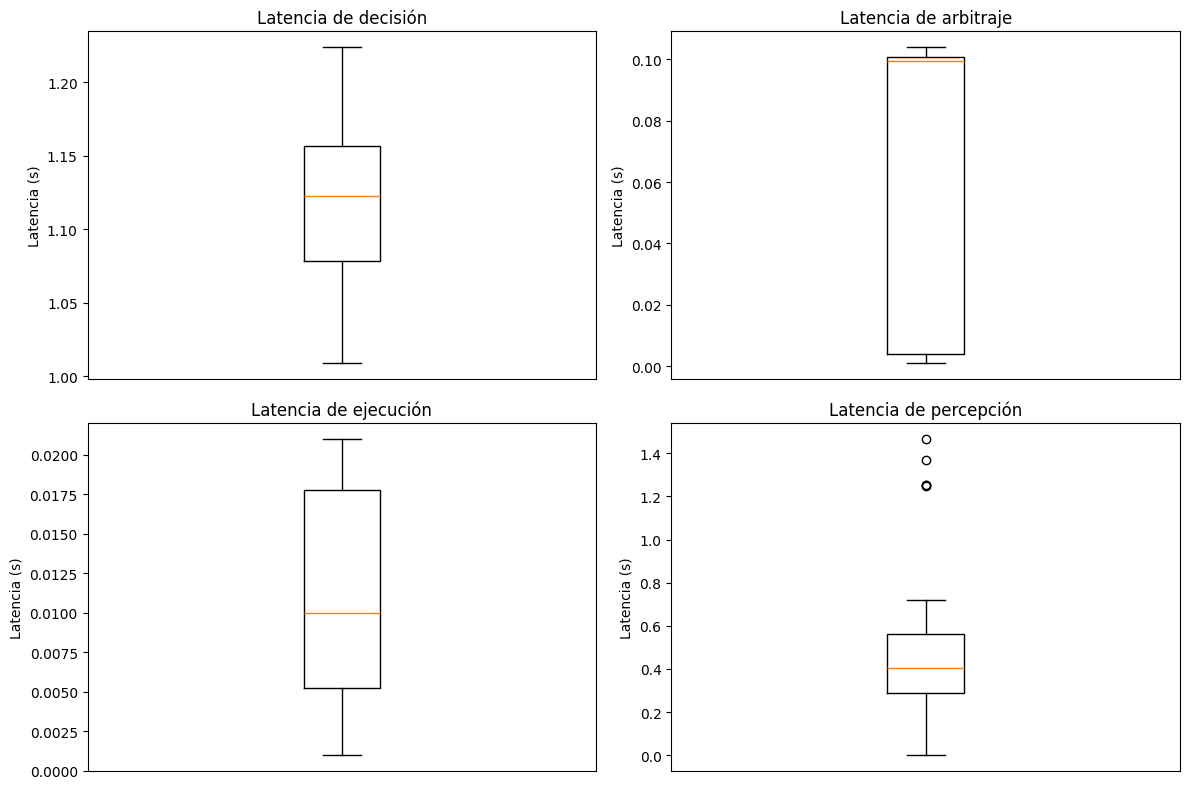

In [267]:

cols = ["L_plan_control","L_mux","L_exec","L_local"]

labels = {
    "L_plan_control": "Latencia de decisión",
    "L_mux": "Latencia de arbitraje",
    "L_exec": "Latencia de ejecución",
    "L_local": "Latencia de percepción"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.boxplot(df_events[col].dropna())
    ax.set_title(labels[col])
    ax.set_ylabel("Latencia (s)")
    ax.set_xticks([])

plt.tight_layout()
plt.show()

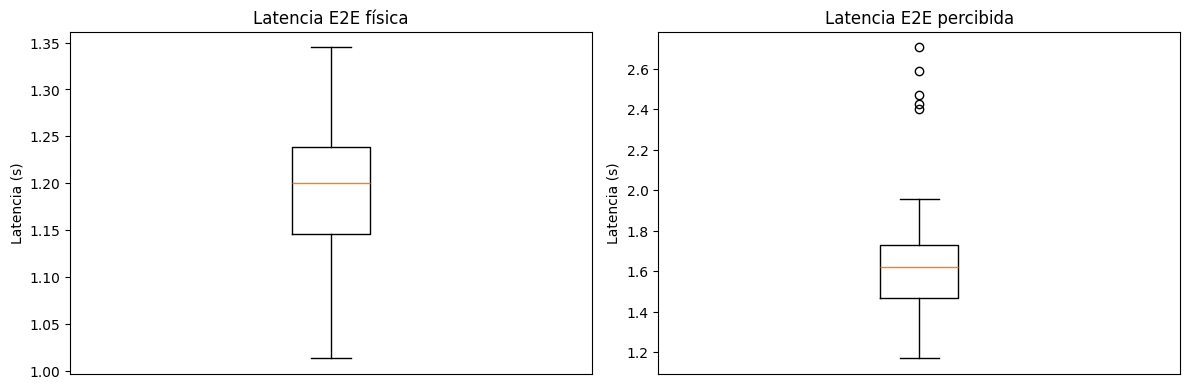

In [268]:
cols = ["L_e2e_odom","L_e2e_amcl"]

labels = {
    "L_e2e_odom": "Latencia E2E física",
    "L_e2e_amcl": "Latencia E2E percibida"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.boxplot(df_events[col].dropna())
    ax.set_title(labels[col])
    ax.set_ylabel("Latencia (s)")
    ax.set_xticks([])
    
plt.tight_layout()
plt.show()


## 8.3. Latencia por goal

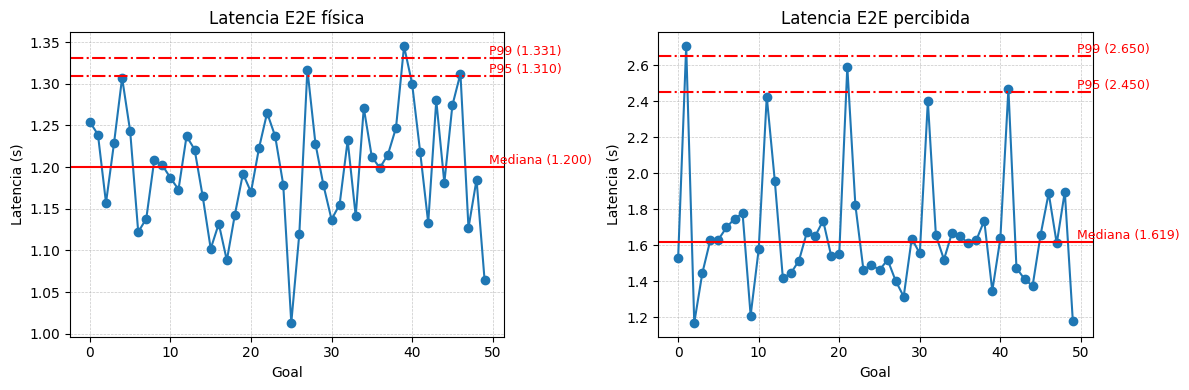

In [269]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cols = ["L_e2e_odom", "L_e2e_amcl"]
titles = ["Latencia E2E física", "Latencia E2E percibida"]

for ax, col, title in zip(axes, cols, titles):
    
    x = df_events["goal_id"]
    y = df_events[col]

    # métricas
    median = y.median()
    p95 = y.quantile(0.95)
    p99 = y.quantile(0.99)

    ax.plot(x, y, marker='o')

    # función local para cada subplot
    def hline(ax, y_val, text, style):
        ax.axhline(y_val, color='red', linestyle=style)
        ax.text(
            x.max(), y_val,
            f" {text} ({y_val:.3f})",
            color='red',
            fontsize=9,
            verticalalignment='bottom'
        )

    # líneas
    hline(ax, median, "Mediana", '-')
    hline(ax, p95, "P95", '-.')
    hline(ax, p99, "P99", '-.')

    ax.set_xlabel("Goal")
    ax.set_ylabel("Latencia (s)")
    ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/e2e_latency_per_goal.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

## 8.4. CDF

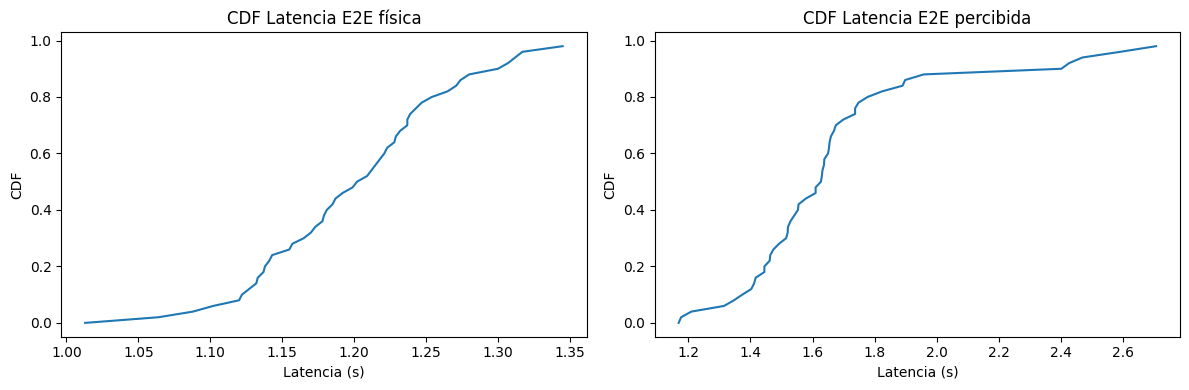

In [270]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cols = ["L_e2e_odom", "L_e2e_amcl"]
titles = ["CDF Latencia E2E física", "CDF Latencia E2E percibida"]


for ax, col, title in zip(axes, cols, titles):
    
    sorted_lat = np.sort(df_events[col])
    cdf = np.arange(len(sorted_lat)) / len(sorted_lat)

    ax.plot(sorted_lat, cdf)
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("CDF")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Grafica de barras apiladas normalizadas (100%)

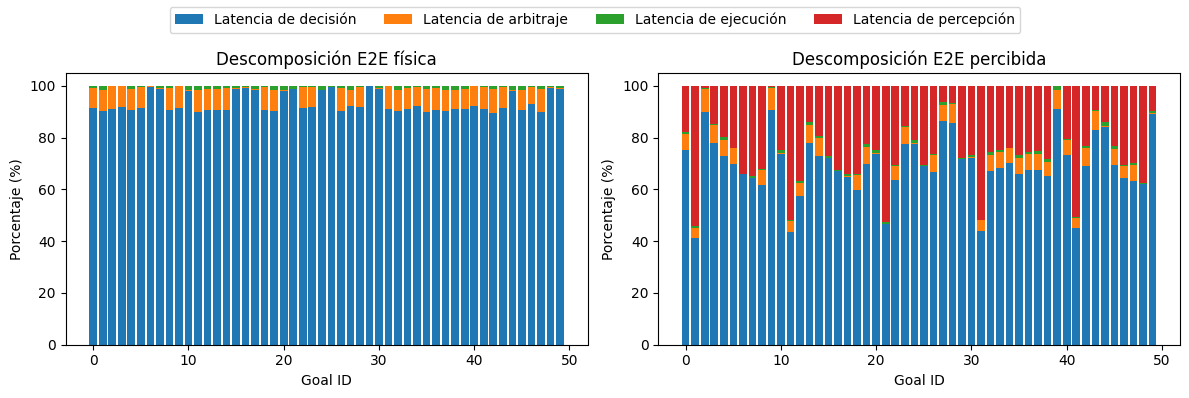

In [271]:
cols_physical = ["L_plan_control", "L_mux", "L_exec"]
cols_perceived = ["L_plan_control", "L_mux", "L_exec", "L_local"]

labels = {
    "L_plan_control": "Latencia de decisión",
    "L_mux": "Latencia de arbitraje",
    "L_exec": "Latencia de ejecución",
    "L_local": "Latencia de percepción"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------
# E2E FÍSICA (ODOM)
# -------------------------
df_plot = df_events.copy()
df_plot = df_plot[df_plot["L_e2e_odom"] > 0]

for col in cols_physical:
    df_plot[col] = df_plot[col] / df_plot["L_e2e_odom"] * 100

bottom = None

for col in cols_physical:
    axes[0].bar(
        df_plot["goal_id"],
        df_plot[col],
        bottom=bottom,
        label=labels[col]
    )
    if bottom is None:
        bottom = df_plot[col].values
    else:
        bottom = bottom + df_plot[col].values

axes[0].set_title("Descomposición E2E física")
axes[0].set_xlabel("Goal ID")
axes[0].set_ylabel("Porcentaje (%)")


# -------------------------
# E2E PERCIBIDA (AMCL)
# -------------------------
df_plot = df_events.copy()
df_plot = df_plot[df_plot["L_e2e_amcl"] > 0]

for col in cols_perceived:
    df_plot[col] = df_plot[col] / df_plot["L_e2e_amcl"] * 100

bottom = None

for col in cols_perceived:
    axes[1].bar(
        df_plot["goal_id"],
        df_plot[col],
        bottom=bottom,
        label=labels[col]
    )
    if bottom is None:
        bottom = df_plot[col].values
    else:
        bottom = bottom + df_plot[col].values

axes[1].set_title("Descomposición E2E percibida")
axes[1].set_xlabel("Goal ID")
axes[1].set_ylabel("Porcentaje (%)")


# Leyenda común
handles, lbls = axes[1].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper center", ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("../../docs/figures/e2e_latency_decomposition.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

# 9. Analisis del jitter

## 9.1 Metricas de jitter

In [272]:
cols = ["L_e2e_odom", "L_e2e_amcl"]

jitter_stats = {}

for col in cols:
    y = df_events[col].sort_index()

    jitter = y.diff().abs().dropna()

    jitter_stats[col] = {
        "mean": y.mean(),
        "std": y.std(),
        "cv": y.std() / y.mean(),
        "jitter_mean": jitter.mean(),
        "jitter_p95": jitter.quantile(0.95),
        "jitter_p99": jitter.quantile(0.99),
    }

jitter_df = pd.DataFrame(jitter_stats).T
print(jitter_df)

               mean       std        cv  jitter_mean  jitter_p95  jitter_p99
L_e2e_odom  1.19796  0.068635  0.057293     0.066776      0.1584     0.19124
L_e2e_amcl  1.66248  0.336119  0.202179     0.327633      1.0208     1.36420


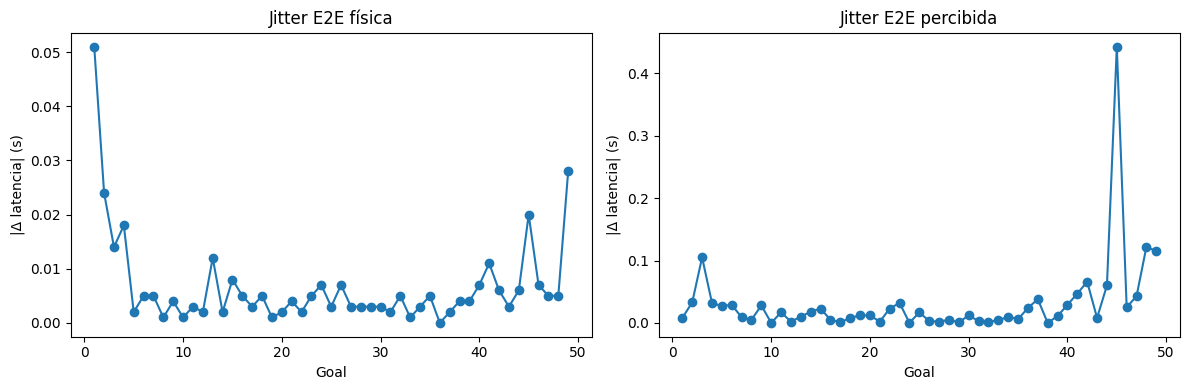

In [273]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cols = ["L_e2e_odom", "L_e2e_amcl"]
titles = ["Jitter E2E física", "Jitter E2E percibida"]

for ax, col, title in zip(axes, cols, titles):
    
    y = df_events[col].sort_values().reset_index(drop=True)
    jitter = y.diff().abs()

    ax.plot(jitter, marker='o')
    ax.set_title(title)
    ax.set_xlabel("Goal")
    ax.set_ylabel("|Δ latencia| (s)")

plt.tight_layout()
plt.show()

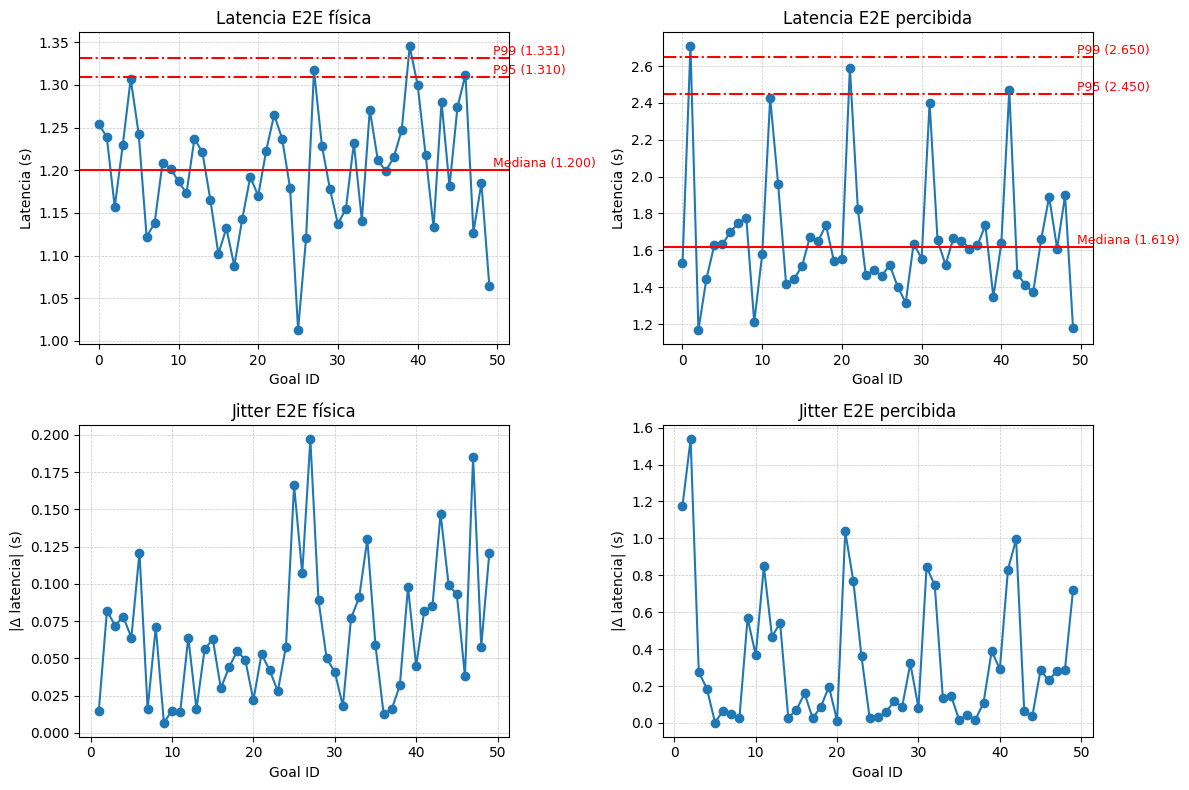

In [274]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

cols = ["L_e2e_odom", "L_e2e_amcl"]

titles_latency = ["Latencia E2E física", "Latencia E2E percibida"]
titles_jitter = ["Jitter E2E física", "Jitter E2E percibida"]

# =========================
# FILA 1 → LATENCIA
# =========================
for i, (col, title) in enumerate(zip(cols, titles_latency)):
    
    ax = axes[0, i]

    x = df_events["goal_id"]
    y = df_events[col]

    # métricas
    median = y.median()
    p95 = y.quantile(0.95)
    p99 = y.quantile(0.99)

    ax.plot(x, y, marker='o')

    def hline(ax, y_val, text, style):
        ax.axhline(y_val, color='red', linestyle=style)
        ax.text(
            x.max(), y_val,
            f" {text} ({y_val:.3f})",
            color='red',
            fontsize=9,
            verticalalignment='bottom'
        )

    hline(ax, median, "Mediana", '-')
    hline(ax, p95, "P95", '-.')
    hline(ax, p99, "P99", '-.')

    ax.set_title(title)
    ax.set_xlabel("Goal ID")
    ax.set_ylabel("Latencia (s)")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


# =========================
# FILA 2 → JITTER
# =========================
for i, (col, title) in enumerate(zip(cols, titles_jitter)):
    
    ax = axes[1, i]

    # IMPORTANTE: mantener orden temporal real (no sort)
    y = df_events.sort_values("goal_id")[col].reset_index(drop=True)
    jitter = y.diff().abs()

    ax.plot(jitter, marker='o')

    ax.set_title(title)
    ax.set_xlabel("Goal ID")
    ax.set_ylabel("|Δ latencia| (s)")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado ---
# plt.savefig("../../docs/figures/e2e_latency_and_jitter.png",
#             dpi=300,
#             transparent=True,
#             bbox_inches='tight')

plt.show()